## 1. Configurações e Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
df = pd.read_excel("data/dataset.xlsx")
df.head()

,Modelo,Idade Veículo,Km,Reclamações,Recall
0,Strada,3,46657,1,Não
1,Pulse,7,123826,4,Sim
2,Fastback,0,17903,1,Não
3,Renegade,6,82040,5,Não
4,Toro,8,144350,7,Sim


## 2. Validação e Pré-processamento do Dataset

### 2.1. Tratamenos básicos

In [3]:
print(f"O Dataset possui {df.shape[1]} colunas e {df.shape[0]} linhas.")

O Dataset possui 5 colunas e 500 linhas.


In [4]:
df.dtypes

Modelo           object
Idade Veículo     int64
Km                int64
Reclamações       int64
Recall           object
dtype: object

In [5]:
# Normalização de informações tipo string:

df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")

for col in df.columns:
    if df[col].dtype == "O":
        df[col] = df[col].str.strip().str.lower().str.replace(" ", "_", regex=False)

df = df.rename(columns={"idade_veículo": "idade_veiculo", "reclamações": "reclamacoes"})
df.head()

,modelo,idade_veiculo,km,reclamacoes,recall
0,strada,3,46657,1,não
1,pulse,7,123826,4,sim
2,fastback,0,17903,1,não
3,renegade,6,82040,5,não
4,toro,8,144350,7,sim


In [6]:
# Proporção da variável target

pd.DataFrame([df["recall"].value_counts(), df["recall"].value_counts(normalize=True)*100]).T

,count,proportion
recall,,
não,261.0,52.2
sim,239.0,47.8


### 2.2. Lidando com NULL e colunas extras

In [7]:
df.isna().sum()

modelo           0
idade_veiculo    0
km               0
reclamacoes      0
recall           0
dtype: int64

## 3. Exploração dos Dados

### 3.1. Variáveis Numéricas

In [8]:
# Pensando em incluir uma variavel que acho interessante, km/idade. Vamos realizar alguns testes
# É importante verificar os casos de idade = 0 para não dar erro na divisão

df["idade_veiculo"].value_counts().sort_index()

idade_veiculo
0    61
1    58
2    59
3    48
4    55
5    56
6    55
7    47
8    61
Name: count, dtype: int64

In [9]:
# Para essa situação, vamos só substituir por 1 para não quebrar o código

df["km_por_ano"] = df["km"] / df["idade_veiculo"].replace(0, 1)

In [10]:
# Olhando para os valores, percebemos uma diferença relativametne interessantes por variável entre com recall e sem recall
# O problema é a variável nova, aparentemente os dois grupos se comportam de maneira muito parecida. Olhando os valores
# Media: 20.4k x 18.9k (~7%)
# Mediana: 18.8k x 18.0k (~4%)

df.groupby("recall")[["km", "idade_veiculo", "reclamacoes", "km_por_ano"]].agg(["mean", "median"]).round(2)

km          idade_veiculo        reclamacoes        km_por_ano  \
            mean   median          mean median        mean median       mean   
recall                                                                         
não     54687.88  47526.0          2.72    2.0        2.60    2.0   20356.29   
sim     94031.88  97149.0          5.26    5.0        4.93    5.0   18885.16   

                  
          median  
recall            
não     18825.00  
sim     17976.14

In [11]:
# Vamos fazer uma analise bi-variada simples de correlação sobre a coluna km_por_ano
# Olhando a correção entre recall e km_por_ano, -0.095 -> muito fraca, mais um ponto para o descarte

# Outro problema que surgiu aqui é a questão de idade_veiculo e km. Elas tem um valor bem alto de correlação entre si. Isso talvez entre como um caso de multicolinearidade. 
# Pensando nas variáveis diremtante, elas dizem coisas muito parecidas, pois carros mais velhos tendem a ter mais KMs rodados mesmo.
# Isso vai ser importante na hora de rodar os modelos.
# Dados que correlação entre elas e o target ser muito próxima (0.4816 e 0.4840), talvez valha utilizar apenas 1, a decidir.

df_corr = df.copy()
df_corr["recall_bin"] = (df_corr["recall"] == "sim").astype(int)
df_corr[["km", "idade_veiculo", "reclamacoes", "km_por_ano", "recall_bin"]].corr()

,km,idade_veiculo,reclamacoes,km_por_ano,recall_bin
km,1.000000,0.947079,0.634056,-0.076125,0.481629
idade_veiculo,0.947079,1.000000,0.664142,-0.296838,0.484029
reclamacoes,0.634056,0.664142,1.000000,-0.207287,0.452101
km_por_ano,-0.076125,-0.296838,-0.207287,1.000000,-0.095307
recall_bin,0.481629,0.484029,0.452101,-0.095307,1.000000


### 3.2. Variáveis Categóricas

In [12]:
# Olhando para o Modelo agora, para ver a relação dela com a target
# Como  é categórica, correlação numérica (tipo Pearson) não vai servir
# O jeito certo de comparar é taxa de recall por grupo, junto com o desgaste médio de cada um (idade/km/reclamações), pra saber se a diferença é um efeito próprio

# Tem bastante bastante casos por categoria, está bem dividido.
# A diferença entre o maior e menor não é tão grande aqui (37.3% x 57.4%) -> diff 20.1%

# É legal ver as infos numéricas aqui para ver se tem um padrão ou não, tipo mais antigo mais recall. O toro parece entrar nisso, maior recall e idade e km os maiores.
# O comppass e o pulse no entanto já não parecem necessariamente seguir issso

resumo_modelo = df.groupby("modelo")["recall"].agg(
                                                total_casos="count",
                                                taxa_recall=lambda x: (x == "sim").mean(),
                                                ).sort_values(by="taxa_recall", ascending=False)

resumo_modelo = resumo_modelo.join(
                                df.groupby("modelo")[["idade_veiculo", "km", "reclamacoes"]].mean().round(1)
                                )

resumo_modelo

,total_casos,taxa_recall,idade_veiculo,km,reclamacoes
modelo,,,,,
toro,54,0.574074,4.4,79738.4,4.1
cronos,51,0.529412,4.2,76872.6,4.0
strada,63,0.523810,4.1,78301.9,3.8
commander,66,0.484848,3.6,68195.6,3.1
argo,54,0.481481,3.4,65323.4,3.7
compass,53,0.471698,4.3,76790.2,3.9
renegade,52,0.442308,3.8,68972.8,3.9
pulse,48,0.416667,4.0,75933.7,3.5
fastback,59,0.372881,3.7,72171.2,3.5


In [13]:
# Pra cravar o que estávemos discutindo antes, rodamos um teste de qui-quadrado entre modelo e recall pois são variáveis categóricas
# Com o resultado de Chi² = 6.69 e p-valor = 0.57007 -> não conseguimos rejeitar a hipótese de indepêndencia, então não da pra saber
# se tem uma relação entre recall e modelo

# Talvez na construção do modelo seja legal deixar de fora, pq as variáveis numéricas pareciam bem mais fortes

from scipy.stats import chi2_contingency

tabela = pd.crosstab(df["modelo"], df["recall"])
chi2, p, dof, expected = chi2_contingency(tabela)
print(f"Chi2: {chi2:.2f}, p-valor: {p:.5f}")

Chi2: 6.69, p-valor: 0.57007


In [14]:
# Olhando para o ano x modelo para dar uma olhada na taxa de recall, é legal ver que todos os modelos 
# estão seguindo um padrão, de aumento de recall com a idade. Isso da uma visualização pq nosso teste
# anterior mostrou baixar significânica, todos seguem esse padrão. 

df["recall_num"] = (df["recall"] == "sim").astype(int)

# Taxa de recall no cruzamento modelo x ano
tabela_taxa = df.pivot_table(
    index="modelo",
    columns="idade_veiculo",
    values="recall_num",
    aggfunc="mean"
)

tabela_taxa.round(2)

idade_veiculo,0,1,2,3,4,5,6,7,8
modelo,,,,,,,,,
argo,0.38,0.14,0.30,0.60,0.20,0.60,1.00,1.00,0.60
commander,0.00,0.00,0.50,0.33,0.80,0.75,0.62,0.83,1.00
compass,0.00,0.00,0.62,0.20,0.33,0.75,0.00,0.88,0.80
cronos,0.00,0.33,0.50,0.33,0.60,0.56,0.71,0.60,1.00
fastback,0.00,0.29,0.20,0.10,0.55,0.60,0.45,0.50,1.00
pulse,0.00,0.33,0.20,0.40,0.25,0.83,0.00,0.67,0.86
renegade,0.00,0.25,0.36,0.00,0.83,0.29,0.38,1.00,1.00
strada,0.00,0.33,0.75,0.57,0.40,0.50,0.86,0.33,0.80
toro,0.00,0.20,0.50,0.40,0.67,0.67,0.75,1.00,0.83


In [15]:
# Apenas para olhar o agregado. Claramente o que comentei antes.

df.groupby("idade_veiculo")["recall"].agg(
    total_casos="count",
    taxa_recall=lambda x: (x == "sim").mean(),
).sort_index()

,total_casos,taxa_recall
idade_veiculo,,
0,61,0.049180
1,58,0.172414
2,59,0.440678
3,48,0.333333
4,55,0.563636
5,56,0.607143
6,55,0.563636
7,47,0.765957
8,61,0.852459


## 4. Escolha de Modelos

### 4.1. Escolha das Features e Separação de Datasets

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
# Não utilizei todas as features analisadas anteriormente. Uma vez que algumas não faziam sentido ficou assim:
# - modelo: não utilizada pois não apresenta força estatística para o modelo
# - idade_veiculo: utilizada pois traz informações importantes de uso do veículo
# - km: removida pois apresenta uma relação muito forte com idade_veiculo, acaba trazendo o memso nível de informação -> vale testar com e sem
# - reclamacoes: utilizada pois aparentemente tem uma relação com recall
# - recall: target que queremos prever

features = ["idade_veiculo", "reclamacoes"]
target = "recall"

In [18]:
X = df[features].copy()
y = df[target].map({"não": 0, "sim": 1})

In [19]:
# Vamos utilizar a estratégia Treino / Validação / Teste -> então teremos 3 datasets
# O ideal é 60% / 20 % / 20% -> como vamos usar o train_test_split, vamos colocar 25% no valor pq ele pega 25% dos 80% do primeiro split, resultando nos 20%

test_size = 0.2
val_size = 0.25
random_state = 42

In [20]:
X_full, X_test, y_full, y_test = train_test_split(
                                                X, 
                                                y, 
                                                test_size=test_size, 
                                                random_state=random_state,
                                                stratify=y
                                                )

In [21]:
X_train, X_val, y_train, y_val = train_test_split(
                                                X_full, 
                                                y_full, 
                                                test_size=val_size, 
                                                random_state=random_state,
                                                stratify=y_full
                                                )

In [22]:
# Validando a estratificação da base nos 3 datasets

(pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Treino": y_train.value_counts(normalize=True),
    "Validação": y_val.value_counts(normalize=True),
    "Teste": y_test.value_counts(normalize=True)
})*100).round(2)

,Original,Treino,Validação,Teste
recall,,,,
0,52.2,52.33,52.0,52.0
1,47.8,47.67,48.0,48.0


In [23]:
print(f"O DF de Treino possui {X_train.shape[1]} colunas e {X_train.shape[0]} linhas.")
print(f"O DF de Validação possui {X_val.shape[1]} colunas e {X_val.shape[0]} linhas.")
print(f"O DF de Teste possui {X_test.shape[1]} colunas e {X_test.shape[0]} linhas.")

O DF de Treino possui 2 colunas e 300 linhas.
O DF de Validação possui 2 colunas e 100 linhas.
O DF de Teste possui 2 colunas e 100 linhas.


### 4.2. Treinar um baseline de alguns modelos

In [24]:
# !pip install feature_engine

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn import metrics
from sklearn.pipeline import Pipeline

# Modelo 1
from sklearn.linear_model import LogisticRegression

# Modelo 2
from sklearn.tree import DecisionTreeClassifier

# Modelo 3
from sklearn import ensemble

#### 4.2.1. Pré processamento

In [26]:
# Pré processamento vai ser bem simples. Geralmente eu deixo essa sessão separada para montar tudo que é em comum nos modelos, como tratar variáveis categóricas, numéricas etc, mas como
# nosso modelo só possui duas features e são categóricas, parece meio redundantes mas é bom manter o padrão
# - Numéricas: apliquei o MinMax para apenas padronizar os valores no intervalo 0 - 1, bem simples

preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), features),
    ]
)

#### 4.2.2. Regressão Logística

In [27]:
# Selecionei um modelo base mais simples de analisar para ter um baseline de saída, só para entender se estamos chegando em algo e como melhorar

reg_log = LogisticRegression(
                        penalty = None,
                        random_state = random_state,
                        max_iter = 1000000
                        )

In [28]:
# Pipeline para rodar as transformações e o modelo

reg_log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", reg_log)
    ]
)

In [29]:
# Aqui já deixei implementado via pipeline para podermos melhorar o pré-processamento de forma mais rápida e simples

reg_log_pipeline.fit(X_train[features], y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
y_train_reg_log_predict = reg_log_pipeline.predict(X_train[features])
y_train_reg_log_proba = reg_log_pipeline.predict_proba(X_train[features])[:, 1]

In [31]:
# A avaliação inicial é entre Treino e Validação
# Vou compilar os modelos juntos a eguir pra poder visualizar juntos

y_val_reg_log_predict = reg_log_pipeline.predict(X_val[features])
y_val_reg_log_proba = reg_log_pipeline.predict_proba(X_val[features])[:, 1]

#### 4.2.3. Árvore de Decisão

In [32]:
# Outro modelo relativamente simples escolhido para testes é um algoritimo de Árvore de Decisão

tree = DecisionTreeClassifier(
                        max_depth=5,
                        min_samples_leaf=20,
                        random_state=random_state
)

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", tree)
    ]
)

tree_pipeline.fit(X_train[features], y_train)

# Métricas de Treino
y_train_tree_predict = tree_pipeline.predict(X_train[features])
y_train_tree_proba = tree_pipeline.predict_proba(X_train[features])[:, 1]

# Métricas de Validação
y_val_tree_predict = tree_pipeline.predict(X_val[features])
y_val_tree_proba = tree_pipeline.predict_proba(X_val[features])[:, 1]

#### 4.2.4. Random Forest

In [33]:
# Outro modelo um pouco mais complexo é o Random Forest

rand_forest = ensemble.RandomForestClassifier(
                        random_state = random_state,
                        min_samples_leaf = 20,
                        n_jobs = -1, # todos os nucleos
                        n_estimators = 1000
                        )

rand_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rand_forest)
    ]
)

rand_forest_pipeline.fit(X_train[features], y_train)

# Métricas de Treino
y_train_rand_forest_predict = rand_forest_pipeline.predict(X_train[features])
y_train_rand_forest_proba = rand_forest_pipeline.predict_proba(X_train[features])[:, 1]

# Métricas de Validação
y_val_rand_forest_predict = rand_forest_pipeline.predict(X_val[features])
y_val_rand_forest_proba = rand_forest_pipeline.predict_proba(X_val[features])[:, 1]

#### 4.2.5. Compilado de Comparação entre Modelos

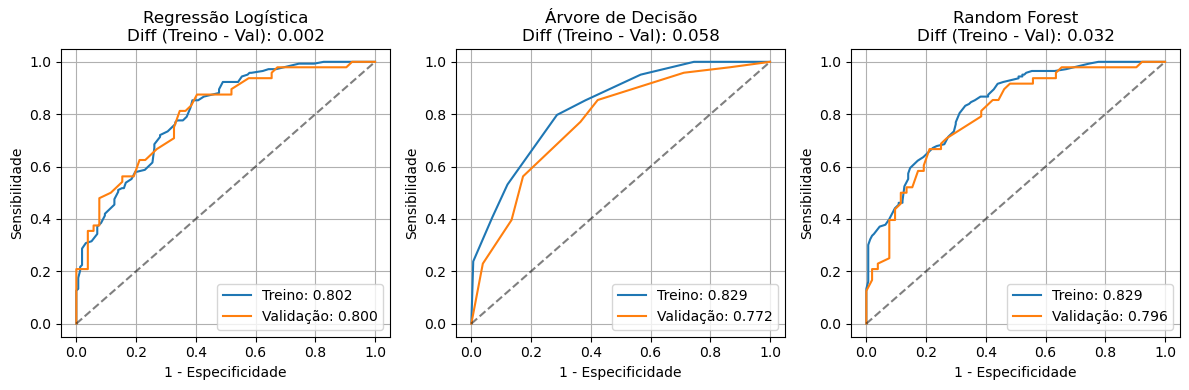

In [34]:
# Curva ROC dos 3 modelos, pra poder ter uma comparação mais visual
# A ideia aqui é dar uma olhada no descolamento entre as curvas de Treino e Validação
# E verificar quanto a mais saimos da linha de refêrencia base

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

modelos = [
    ("Regressão Logística", y_train_reg_log_proba, y_val_reg_log_proba),
    ("Árvore de Decisão", y_train_tree_proba, y_val_tree_proba),
    ("Random Forest", y_train_rand_forest_proba, y_val_rand_forest_proba)
]

for ax, (nome, proba_train, proba_val) in zip(axes, modelos):

    roc_train = metrics.roc_curve(y_train, proba_train)
    roc_val = metrics.roc_curve(y_val, proba_val)
    auc_train = metrics.roc_auc_score(y_train, proba_train)
    auc_val = metrics.roc_auc_score(y_val, proba_val)
    
    diff = auc_train - auc_val
    
    ax.plot(roc_train[0], roc_train[1], label=f"Treino: {auc_train:.3f}")
    ax.plot(roc_val[0], roc_val[1], label=f"Validação: {auc_val:.3f}")
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5) 
    
    ax.set_title(f"{nome}\nDiff (Treino - Val): {diff:.3f}")
    ax.set_xlabel("1 - Especificidade")
    ax.set_ylabel("Sensibilidade")
    ax.grid(True)
    ax.legend(loc="lower right")

plt.tight_layout()

plt.savefig('images/01_auc_roc_three_models.png')

plt.show()

In [35]:
# Da para perceber um bom comportamento nos 3 modelos nessa métrica. As curvas não se descolam tanto entre Treino e Validação, apenas a Árvore que aparecentemente
# deu uma overfittada. Mas Reg Log e RF parecebem bem boas. A RF também teve um ótimo desempenho em treino, mas é um modelo um pouco menos interpretativo, então
# vou olhar outras métricas também. 

In [36]:
modelos_proba_val = {
    "Regressão Logística": y_val_reg_log_proba,
    "Árvore de Decisão": y_val_tree_proba,
    "Random Forest": y_val_rand_forest_proba,
}

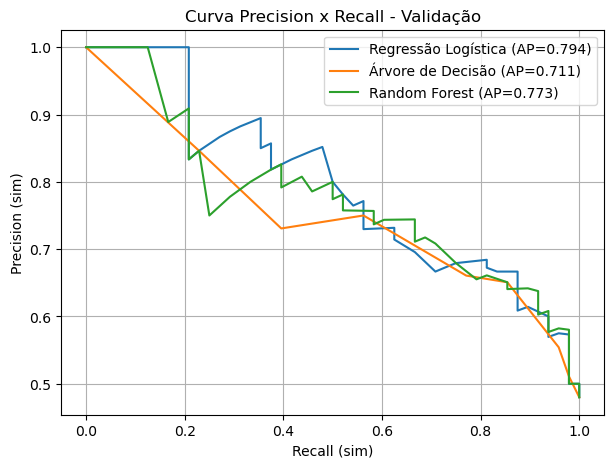

In [37]:
# Aqui olhei de fato para as métricas dos modelos de forma direta para visualizar quem está desempenhando melhor
# ao alterarmos um limiar de recall.
# O modelo de Árvore apresenta um comportamento que salta em alguns pontos, parecendo que para esse dataset não é o mais adequado.
# Focando entre RF e Regressão Logística, as curvas ficam bem próximas e se cruzam em vários pontos do gráfico - ou seja,
# tem regiões de recall em que o RF tem uma precisão um pouco melhor, e outras em que a Reg Log fica na frente.
# Olhando o Average Precision (área sob a curva), a Reg Log leva uma pequena vantagem sobre o RF

plt.figure(figsize=(7, 5))

for nome, proba_val in modelos_proba_val.items():
    precision, recall, _ = metrics.precision_recall_curve(y_val, proba_val)
    ap = metrics.average_precision_score(y_val, proba_val)
    plt.plot(recall, precision, label=f"{nome} (AP={ap:.3f})")

plt.xlabel("Recall (sim)")
plt.ylabel("Precision (sim)")
plt.title("Curva Precision x Recall - Validação")
plt.legend()
plt.grid(True)
plt.show()

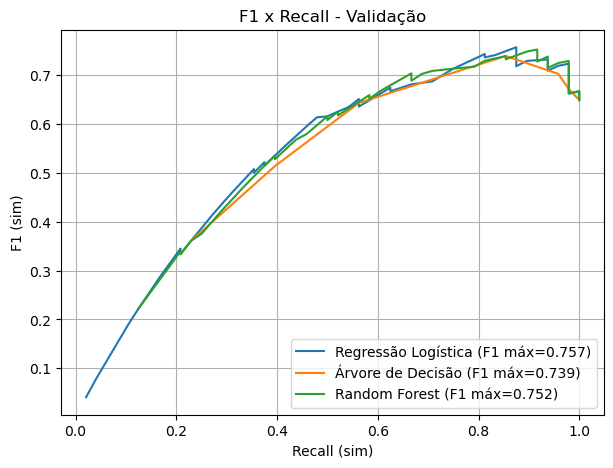

In [38]:
# Aqui a ideia é a mesma, e novamente Log Reg parece um pouco melhor.
# Em boa parte do gráfico eles ficam empatados, inclusive a Arvore, mas
# olhando o F1 max, reg log ganha um pouquinho


plt.figure(figsize=(7, 5))

for nome, proba_val in modelos_proba_val.items():
    precision, recall, thresholds = metrics.precision_recall_curve(y_val, proba_val)
    precision, recall = precision[:-1], recall[:-1]
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    max_f1 = f1.max()
    plt.plot(recall, f1, label=f"{nome} (F1 máx={max_f1:.3f})")

plt.xlabel("Recall (sim)")
plt.ylabel("F1 (sim)")
plt.title("F1 x Recall - Validação")
plt.legend()
plt.grid(True)
plt.show()

#### 4.2.6. K-Fold Validation (extra)

In [39]:
# Os 2 modelos (RF e Reg Log) ficaram muito próximos nas métricas de Validação que fizemos, e o de árvore pareceu se comportar
# um pouco estranho, overfitando até. Então ele foi descardado e decidi fazer um ultimo teste aqui, geralmente só faço quando 
# estão muito próximos os modelos. Vou rodar o K-Fold nos 2 ao mesmo tempo, no Full Train (Treino + Validação), pra comparar de 
# forma mais robusta se eles são estáveis.

from sklearn.model_selection import StratifiedKFold, cross_validate

In [40]:
X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

print(f"Full Train: {X_full_train.shape[0]} linhas")

Full Train: 400 linhas


In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

modelos_cv = {
    "Regressão Logística": reg_log_pipeline,
    "Random Forest": rand_forest_pipeline
}

linhas_cv = []

In [42]:
# Adicionando o desvio de precision e recall também, pra confirmar se a diferença de recall
# entre RF e Regressão Logística é real ou só mais uma variação de amostra entre os folds.

linhas_cv = []

for nome, pipeline in modelos_cv.items():
    resultado = cross_validate(
        pipeline,
        X_full_train[features],
        y_full_train,
        cv=cv,
        scoring=["f1", "roc_auc", "precision", "recall"],
        return_train_score=True
    )
    linhas_cv.append({
        "modelo": nome,
        "roc_auc_media": resultado["test_roc_auc"].mean(),
        "roc_auc_std": resultado["test_roc_auc"].std(),
        "f1_media": resultado["test_f1"].mean(),
        "f1_std": resultado["test_f1"].std(),
        "precision_media": resultado["test_precision"].mean(),
        "precision_std": resultado["test_precision"].std(),
        "recall_media": resultado["test_recall"].mean(),
        "recall_std": resultado["test_recall"].std(),
    })

pd.DataFrame(linhas_cv).round(3)

,modelo,roc_auc_media,roc_auc_std,f1_media,f1_std,precision_media,precision_std,recall_media,recall_std
0,Regressão Logística,0.799,0.057,0.684,0.08,0.690,0.061,0.682,0.103
1,Random Forest,0.804,0.048,0.697,0.09,0.668,0.068,0.739,0.137


In [43]:
# Conclusão da escolha do modelo:
# Comparando Regressão Logística, Árvore de Decisão e Random Forest em várias métricas
# (AUC-ROC, Average Precision, F1 máximo) na Validação, e os 3 primeiros, especialmente
# RF e Regressão Logística, ficaram muito próximos, sem um vencedor claro.

# Para não decidir com base em um único split de Validação (só 100 linhas), rodei o
# K-Fold no Full Train comparando RF e Regressão Logística diretamente.
# Resultado: em AUC, F1, Precision e Recall, a diferença entre os dois modelos foi sempre
# menor que o desvio-padrão entre os folds de cada um, posso dizer que estatisticamente eles
# empatam nesse dataset.
# Por causa disso, optei pela Regressão Logística: ela é mais simples,
# mais estável entre os folds (desvios menores em quase todas as métricas) e muito mais
# interpretável, o que é importante tanto para a robustez do modelo quanto para comunicar a decisão
# de negócio.

## 5. Modelo Escolhido: Regressão Logística

### 5.1. Tunning dos Hiperparâmetros

In [44]:
from sklearn.model_selection import GridSearchCV

# Com o modelo escolhido vou realizar um tunning simples nos parâmetros
# Fixei penalty="l2" no grid porque é o tipo de regularização padrão e compatível com o
# solver que já to usando
# Usei AUC como critério de otimização,pq é a métrica mais estável
# entre os folds e não depende de escolher um limiar.
# O tuning é feito só em X_train (não no Full Train)

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
}

grid_search = GridSearchCV(
    estimator=reg_log_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train[features], y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...)]"


In [45]:
# Olhando como o AUC varia conforme a força de regularização (C), pra ver se algum valor
# realmente melhora em relação ao baseline (penalty=None) ou se, como no RF, a diferença
# é mais ruído do que ganho real dado o tamanho pequeno da base.

resultados = pd.DataFrame(grid_search.cv_results_)
resultados[["param_model__C", "mean_test_score", "std_test_score", "mean_train_score"]].sort_values(
    by="mean_test_score", ascending=False
).head(10)

,param_model__C,mean_test_score,std_test_score,mean_train_score
0,0.01,0.802108,0.061408,0.802562
1,0.10,0.802108,0.061408,0.802562
2,1.00,0.800326,0.061028,0.802576
3,10.00,0.799659,0.058140,0.802061
4,100.00,0.799659,0.058140,0.802019


In [46]:
# Os resultados do tuning não foram tão interessantes nesse momento porque o AUC
# quase não muda entre os valores de C testados (varia de 0.7997 a 0.8021)
# Com uma base pequena e sintética, o tuning tende a não mudar muito o resultado
# Um ponto interessante: o AUC de treino fica bem próximo do AUC de validação em todos os
# valores, o que reforça que a Regressão Logística não está overfitando, mesmo
# com pouca regularização
# A fim de manter um padrão de processo, vou utilizar os parâmetros indicados como melhores 
# porque não vai atrapalhar nada

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor AUC (CV):", round(grid_search.best_score_, 4))

Melhores parâmetros: {'model__C': 0.01, 'model__penalty': 'l2'}
Melhor AUC (CV): 0.8021


### 5.2. Escolha o melhor threshold 

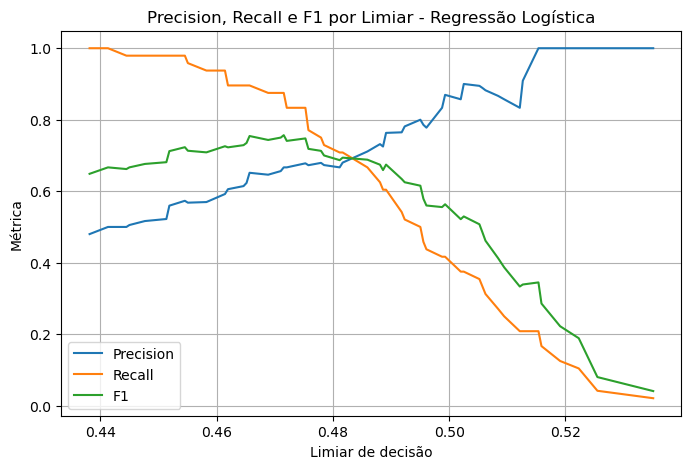

In [47]:
# Depois de comparar os modelos entre si e de tunar a Regressão Logística agora vou calibrar
# o limiar de decisão usando o modelo tunado
# A decisão desse valor geralmente é mais baseada no problema que a gente quer resolver resolver,
# tradeoffs, etc, então não é tão simples numa base sintética. Para ajudar aqui vou utilizar o
# gráfico para comparar as métricas dentro do modelo de Regressão Logística

# Aqui por exemplo, eu imagino que um Falso Negativo é pior que um Falso Positivo em termos de
# risco. Porque mesmo que analisemos mais carros com FP (custo), o problema de deixar passar
# carros que precisariam de um recall de fato (FN) parece bem pior

# Como não tenho esses custos para uma análise mais profunda, eu decidi optar por utilizar o
# ponto de maximização do F1-score, porque ele me dá um bom equilíbrio entre Precisão x Recall

y_val_reg_log_tunado_proba = grid_search.best_estimator_.predict_proba(X_val[features])[:, 1]

precision, recall, thresholds = metrics.precision_recall_curve(y_val, y_val_reg_log_tunado_proba)

precision, recall = precision[:-1], recall[:-1]
f1 = 2 * precision * recall / (precision + recall + 1e-9)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision, label="Precision")
plt.plot(thresholds, recall, label="Recall")
plt.plot(thresholds, f1, label="F1")
plt.xlabel("Limiar de decisão")
plt.ylabel("Métrica")
plt.title("Precision, Recall e F1 por Limiar - Regressão Logística")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# Olhando o valor exato e métricas no ponto:

melhor_limiar = thresholds[np.argmax(f1)]
print("Limiar que maximiza F1:", round(melhor_limiar, 4))
print("Precision nesse ponto:", round(precision[np.argmax(f1)], 4))
print("Recall nesse ponto:", round(recall[np.argmax(f1)], 4))
print("F1 nesse ponto:", round(f1.max(), 4))

Limiar que maximiza F1: 0.4715
Precision nesse ponto: 0.6667
Recall nesse ponto: 0.875
F1 nesse ponto: 0.7568


In [49]:
limiar_final = 0.4715

### 5.2. Treino do modelo final

In [50]:
# Treinei o modelo final agora com tudo decidido de parâmetros e vou utilizar o Full Train porque vou usar a base de Teste apenas para verificar o funcionamento,
# não decidir nada (que é a ideia dela).

final_reg_log = LogisticRegression(
    C=grid_search.best_params_["model__C"],
    penalty=grid_search.best_params_["model__penalty"],
    random_state=random_state,
    max_iter=1000000
)

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_reg_log)
])

final_pipeline.fit(X_full_train[features], y_full_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


AUC [Teste]: 0.7722

              precision    recall  f1-score   support

           0       0.72      0.69      0.71        52
           1       0.68      0.71      0.69        48

    accuracy                           0.70       100
   macro avg       0.70      0.70      0.70       100
weighted avg       0.70      0.70      0.70       100



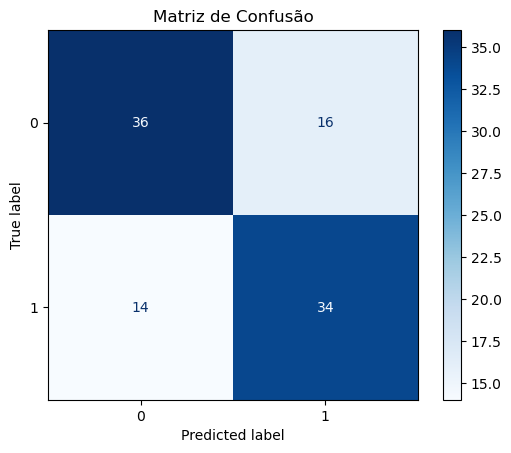

In [51]:
# Agora sim vou utilizar a base de teste para confirmar o que já vimos em Treino/Validação.

y_test_proba = final_pipeline.predict_proba(X_test[features])[:, 1]
y_test_pred = (y_test_proba >= limiar_final).astype(int)

print("AUC [Teste]:", round(metrics.roc_auc_score(y_test, y_test_proba), 4))
print()
print(metrics.classification_report(y_test, y_test_pred))

# === Geração da Matriz Visual ===
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_test_pred, 
    cmap="Blues",
    values_format="d"
)
disp.ax_.set_title("Matriz de Confusão")

plt.savefig('images/03_confusion_matrix_final_model.png')

plt.show()

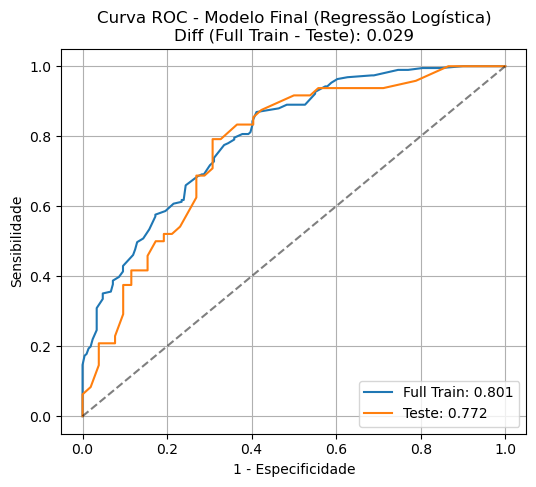

In [52]:
# Curva ROC do modelo final, comparando a performance no próprio Full Train com o Teste 

y_full_train_proba = final_pipeline.predict_proba(X_full_train[features])[:, 1]

roc_full_train = metrics.roc_curve(y_full_train, y_full_train_proba)
roc_test = metrics.roc_curve(y_test, y_test_proba)

auc_full_train = metrics.roc_auc_score(y_full_train, y_full_train_proba)
auc_test = metrics.roc_auc_score(y_test, y_test_proba)

diff = auc_full_train - auc_test

plt.figure(figsize=(6, 5))
plt.plot(roc_full_train[0], roc_full_train[1], label=f"Full Train: {auc_full_train:.3f}")
plt.plot(roc_test[0], roc_test[1], label=f"Teste: {auc_test:.3f}")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("1 - Especificidade")
plt.ylabel("Sensibilidade")
plt.title(f"Curva ROC - Modelo Final (Regressão Logística)\nDiff (Full Train - Teste): {diff:.3f}")
plt.grid(True)
plt.legend(loc="lower right")

plt.savefig('images/02_auc_roc_final_models.png')

plt.show()

## 6. Interpretação do Modelo

In [53]:
# Extraindo os coeficientes do modelo final e desfazendo o efeito do MinMaxScaler, para
# poder interpretar em unidades reais
# Isso aqui é necessário pq o Scaler deixou tudo entre 0 e 1 e não faz muito sentido com
# os dados práticos que ja temos aqui

scaler_num = final_pipeline.named_steps["preprocessor"].named_transformers_["num"]
modelo_final = final_pipeline.named_steps["model"]

coef_escala = modelo_final.coef_[0]     
intervalo = scaler_num.data_range_         

coef_unidade_real = coef_escala / intervalo   
odds_ratio = np.exp(coef_unidade_real)        

interpretacao = pd.DataFrame({
    "feature": features,
    "coef_escala_0_1": coef_escala.round(4),
    "coef_por_unidade_real": coef_unidade_real.round(4),
    "odds_ratio_por_unidade_real": odds_ratio.round(4)
})

interpretacao

,feature,coef_escala_0_1,coef_por_unidade_real,odds_ratio_por_unidade_real
0,idade_veiculo,0.2878,0.0360,1.0366
1,reclamacoes,0.1579,0.0121,1.0122


In [54]:
print(f"idade veiculo: {np.exp(0.2878):.4f}")
print(f"reclamacoes: {np.exp(0.1579):.4f}")

idade veiculo: 1.3335
reclamacoes: 1.1710


In [55]:
# ===================================================================================================================
#                                                INTERPRETAÇÃO DO MODELO
# ===================================================================================================================

# -------------------------------------------- Variáveis mais relevantes --------------------------------------------

# O modelo final (Regressão Logística) usa duas variáveis: idade_veiculo e reclamacoes.

# Ambas as variáveis aumentam a chance de recall na mesma direção que já foi visto na EDA
# - idade_veiculo: cada ano adicional multiplica a chance de recall por 1.0366 (+3.66%)
# - reclamacoes: cada reclamação adicional multiplica a chance de recall por 1.0122 (+1.22%)

# Como são em escalas diferentes, olhei para coef_escala_0_1 para a comparação entre elas
# Da pra falar que que a idade do carro tem um peso maior, porque aumenta a chance de 
# recall em ~33%, enquanto sair de 0 pro máximo de reclamações aumenta em ~17%.
# Isso sugere que, embora ambas as variáveis contribuam, a idade do veículo é o fator mais
# relevante para prever recall nesse dataset.

# A variavel modelo e km foram dropadas:
# - modelo: por não apresentar associação estatística significativa com o recall (qui-quadrado, p=0.570)
# - km: por sua forte correlação com idade_veiculo (multicolinearidade)

# -------------------------------------------- Limitações do modelo --------------------------------------------------

#    1. Base pequena (500 linhas, 300/100/100 no split): como tinha poucos valores para treinar
# e avaliar o modelo, algumas métricas não ficaram tão estáveis. Mas com o valor de casos que
# foram disponibilizados, os valores são bem legais

#    2. Poucas variáveis disponíveis: o modelo final usa só idade_veiculo e reclamacoes. Isso
# simplifica a interpretação, mas pode deixar de capturar outras causas reais de recall que não 
# estão no dataset

#    3. modelo do carro foi descartado por não ter associação significativa mas com uma base
# de só 500 linhas, o teste qui-quadrado tem pouco poder estatístico. Não é possível afirmar com 
# confiança que o modelo do carro realmente não importa, só que não há evidência suficiente nesse dataset.

#    4. Ausência de custo real de negócio: o limiar de decisão (0.4715) foi calibrado simplesmenete
# maximizando o F1-scorel, mas seria muito importante avaliar o custo no negócio esse calibramento,
# porque no mundo real recall de carro bom x não recall de carro ruim é bem diferente

#    5. Suposição não verificável: assumimos que reclamacoes é registrada antes da decisão de
# recall para evitar data leakage. No mundo real isso seria uma questão muito importante de ser confirmada
# pois claramente se for uma reclamação pós recall, ela acaba sendo resultado do próprio evento que eu queria prever

## 7. Salvando o modelo

In [56]:
import joblib

joblib.dump(final_pipeline, 'modelo_recall.pkl')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!
